In [1]:
import sys
from pathlib import Path
import psycopg2
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sqlalchemy import create_engine

src_path = Path.cwd().parent / "src"
sys.path.append(str(src_path))

from PreProcessing import clr_transform, presence_absence


In this notebook I want to filter outlier samples and process each dataset for ML applications later on.
I don't want to filter away any taxa at this step yet. I want to retain as much data for each sample that I can get. 
Downstream I will look more closely into which taxa could be removed or filtered away to reduce the number of dimensions for each data set, but at this point I would not want to remove any features. 

In [2]:
db_user = os.environ.get("POSTGRES_USER")
db_pass = os.environ.get("POSTGRES_PASSWORD")
db_host = os.environ.get("POSTGRES_HOST")
db_name = os.environ.get("POSTGRES_DB")

engine = create_engine(f"postgresql+psycopg2://{db_user}:{db_pass}@{db_host}:5432/{db_name}")

In [3]:
wirbelj_relab = pd.read_sql("SELECT * FROM wirbelj_relab", con=engine)
vogtmanne_relab = pd.read_sql("SELECT * FROM vogtmanne_relab", con=engine)

I want to get an understanding of how the data looks like. Preferably I want to find out if there are outlier taxa or samples which may skew models. 

In [4]:
# First map out averge total abundance of each data set for each sample.
wirbelj_relab['total_ab'] = wirbelj_relab.iloc[:,:-2].sum(axis=1)
vogtmanne_relab['total_ab'] = vogtmanne_relab.iloc[:,:-2].sum(axis=1)
wirbelj_relab_sorted = wirbelj_relab.sort_values(by=['total_ab'], ascending=False).iloc[:, -3:]
vogtmanne_relab_sorted = vogtmanne_relab.sort_values(by=['total_ab'], ascending=False).iloc[:, -3:]


<Axes: title={'center': 'total_ab'}, xlabel='[disease]'>

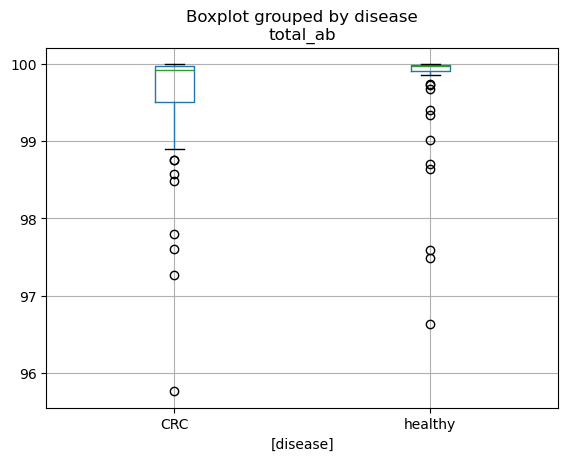

In [5]:
wirbelj_relab_sorted.boxplot(by="disease")

There isn't a clear cut off here between the two groups. It is clear that the healthy cohort has, on average, a higher total abundance than the cancer cohort. 
A good enough cut-off here would be 98%; removed samples would be oultiers in each respective cohort and the remaining samples would have an almost complete profile, only missing at most 2%. 

<Axes: title={'center': 'total_ab'}, xlabel='[disease]'>

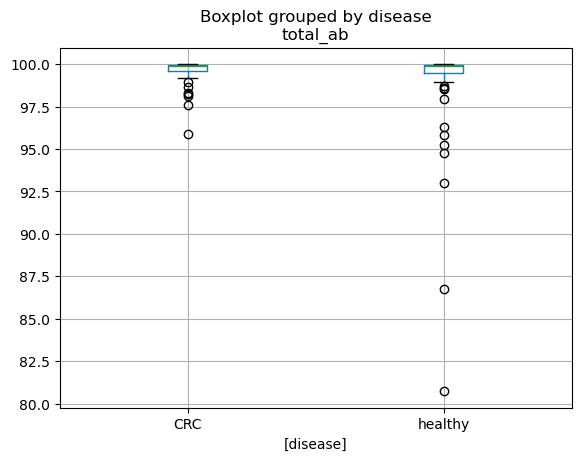

In [6]:
vogtmanne_relab_sorted.boxplot(by="disease")

For the Vogetamann dataset the situation is reversed; most samples in the cancer cohort have a higher total abundance than the healthy cohort.
I would argue that, just as with the WirbelJ dataset, a cut off at 98% can be justified. This removes all outliers in each cohort while remaining samples retain the majority, 98%, of their taxanomic profile. 
As to why these could be samples with such low total abundance; before saving the datasets from my R script, I made sure that each dataset only contained taxa which intersect between them; reducing the dimensionality problem while simplifying comprarissons between each dataset. 

In [7]:
# Filter total abundace: limit 98%. Samples below this threshold are discareded.
wirbelj_relab_sorted_filtered = wirbelj_relab_sorted[wirbelj_relab_sorted['total_ab']>98]


print(wirbelj_relab_sorted['disease'].value_counts())

print(wirbelj_relab_sorted_filtered['disease'].value_counts())
# A modest amount of samples that were removed. Now the abundaces are more similar to each other. 

disease
healthy    65
CRC        60
Name: count, dtype: int64
disease
healthy    62
CRC        56
Name: count, dtype: int64


<Axes: title={'center': 'total_ab'}, xlabel='[disease]'>

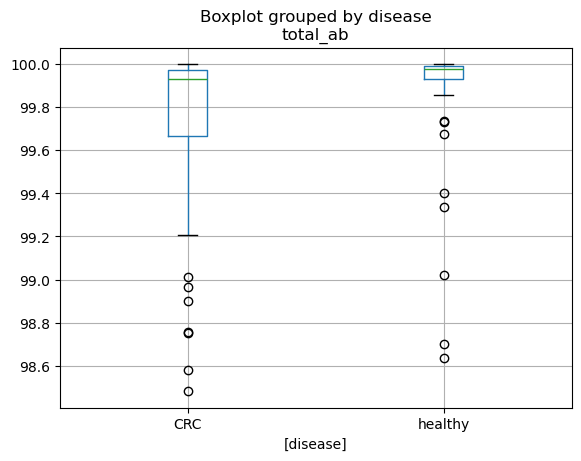

In [8]:
wirbelj_relab_sorted_filtered.boxplot(by="disease")

Each class lost a few samples but the proportion lost in each class is similar: 
Healthy: 65 -> 62 (3/65 ≈ 4.6%)
CRC: 60 -> 56 (4/56 ≈ 7.1%)
There isn't a neat 50/50 split between the classes in this dataset but very close, this won't be a bigger problem for downstream analysis. If there were a more egregious inbalance between the two classes this should be handled. SMOTE (Synthetic Minority Over-sampling Technique) could be used for this end to create synthetic samples from the minority class. 

In [9]:
# Same cut-off for Vogetmann as with WirbelJ. 
vogtmanne_relab_sorted_filtered = vogtmanne_relab_sorted[vogtmanne_relab_sorted['total_ab']>98]

print(vogtmanne_relab_sorted['disease'].value_counts())

print(vogtmanne_relab_sorted_filtered['disease'].value_counts())

disease
healthy    58
CRC        52
Name: count, dtype: int64
disease
CRC        50
healthy    50
Name: count, dtype: int64


<Axes: title={'center': 'total_ab'}, xlabel='[disease]'>

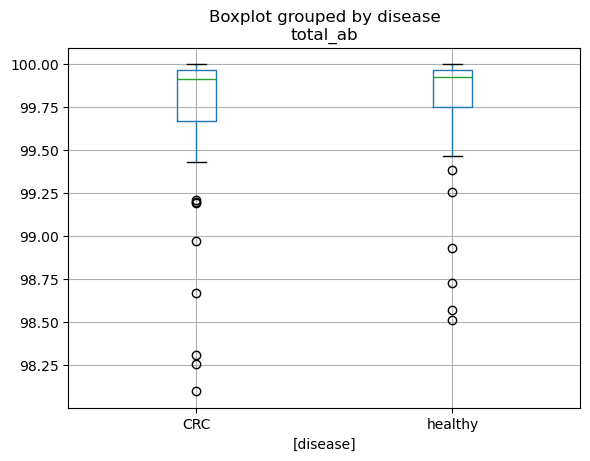

In [10]:
vogtmanne_relab_sorted_filtered.boxplot(by="disease")

Conventiently we end up with a straight 50/50 divide between both classes in the dataset; 50 samples are CRC samples and 50 are healthy samples. Perfect proportions. Each group lost a few samples: Healthy lost the most with 8 samples and CRC lost 2 samples.
Now that outliers have been handled with, each dataset will be processed and saved to the Postgres DB container. 

In [11]:
# Create a seperate data set which is processed for ML applications. This involves performinng a CLR transformation in addition to Z-scaling the transformed data
wirbelj_relab_filtered = wirbelj_relab[wirbelj_relab.index.isin(wirbelj_relab_sorted_filtered.index)].copy()

# Encode a new column. Follows a better intuition than 'disease' column. 
wirbelj_relab_filtered['Healthy'] = wirbelj_relab_filtered['disease'].replace({'healthy': 1, 'CRC': 0})
wirbelj_relab_filtered_clr = clr_transform(wirbelj_relab_filtered.drop(columns=['disease','total_ab','Sample_name','Healthy']))
wirbelj_relab_filtered_presence_absence = presence_absence(wirbelj_relab_filtered.drop(columns=['disease','total_ab','Sample_name','Healthy']))

wirbelj_relab_filtered_clr['Healthy'] = wirbelj_relab_filtered['Healthy']
wirbelj_relab_filtered_presence_absence['Healthy'] = wirbelj_relab_filtered['Healthy']
wirbelj_relab_filtered = wirbelj_relab_filtered.drop(columns=["disease","total_ab","Sample_name"])

In [12]:
# Process Vogtemann dataset
vogtemann_relab_filtered = vogtmanne_relab[vogtmanne_relab.index.isin(vogtmanne_relab_sorted_filtered.index)].copy()
vogtemann_relab_filtered['Healthy'] = vogtemann_relab_filtered['disease'].replace({'healthy': 1, 'CRC': 0})
vogtemann_relab_filtered_clr = clr_transform(vogtemann_relab_filtered.drop(columns=['disease','total_ab','Sample_name','Healthy']))
vogtemann_relab_filtered_presence_absence = presence_absence(vogtemann_relab_filtered.drop(columns=['disease','total_ab','Sample_name','Healthy']))

vogtemann_relab_filtered_clr['Healthy'] = vogtemann_relab_filtered['Healthy']
vogtemann_relab_filtered_presence_absence['Healthy'] = vogtemann_relab_filtered['Healthy']
vogtemann_relab_filtered = vogtemann_relab_filtered.drop(columns=["disease","total_ab","Sample_name"])

In [13]:
# Save processed data
vogtemann_relab_filtered.to_sql(name="vogtemann_relab_filtered",con=engine,if_exists="replace",index=False)
vogtemann_relab_filtered_presence_absence.to_sql(name="vogtemann_relab_filtered_presence_absence",con=engine,if_exists="replace",index=False)
vogtemann_relab_filtered_clr.to_sql(name="vogtemann_relab_filtered_clr",con=engine,if_exists="replace",index=False)


wirbelj_relab_filtered_clr.to_sql(name="wirbelj_relab_filtered_clr",con=engine,if_exists="replace",index=False)
wirbelj_relab_filtered_presence_absence.to_sql(name="wirbelj_relab_filtered_presence_absence",con=engine,if_exists="replace",index=False)
wirbelj_relab_filtered.to_sql(name="wirbelj_relab_filtered",con=engine,if_exists="replace",index=False)

46